# **IMPORT LIBRARIES**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **LOAD DATASET**

In [5]:

file_path = ".csv"

In [6]:

df = pd.read_csv(file_path)

FileNotFoundError: [Errno 2] No such file or directory: '.csv'

In [ ]:

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)

Dataset Loaded Successfully
Shape of dataset: (25000, 25)


FEATURE IMPORTANCE

In [ ]:
coef_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Coefficient": lr_A.coef_[0]
})

coef_df["Abs_Coefficient"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
8,delivery_cost,3.001454,3.001454
9,expected_time_hours_recon,-2.696871,2.696871
6,distance_km,-1.828539,1.828539
21,bad_weather_flag,0.937207,0.937207
3,delivery_mode,-0.937034,0.937034
12,order_month,-0.789705,0.789705
4,region,0.771222,0.771222
5,weather_condition,0.410233,0.410233
7,package_weight_kg,-0.389086,0.389086
23,weather_distance_risk,0.313965,0.313965


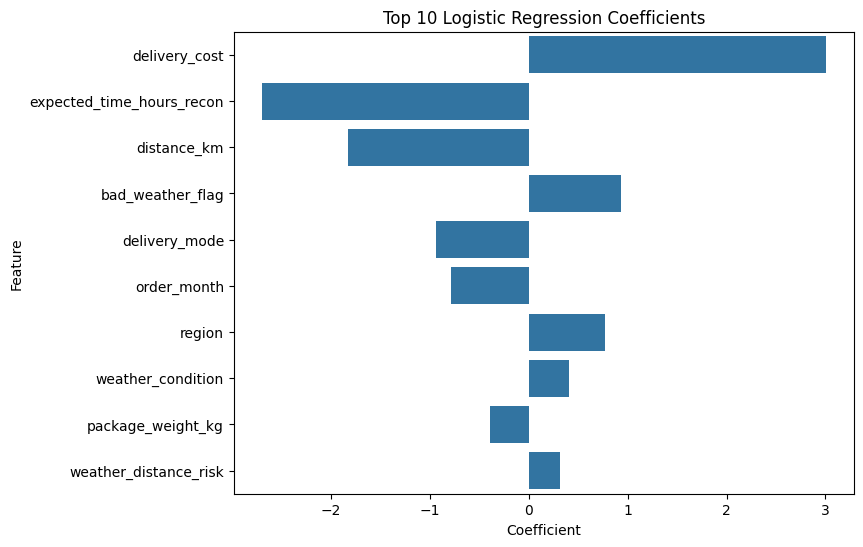

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=coef_df.head(10),
            x="Coefficient",
            y="Feature")
plt.title("Top 10 Logistic Regression Coefficients")
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lr_A,
    X_test_A_sc,
    y_test_A,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df.head(10)

,Feature,Importance
9,expected_time_hours_recon,0.234352
8,delivery_cost,0.160088
6,distance_km,0.048928
21,bad_weather_flag,0.026097
3,delivery_mode,0.014015
12,order_month,0.013815
4,region,0.010159
5,weather_condition,0.005321
7,package_weight_kg,0.003334
23,weather_distance_risk,0.002882


🥇 Most Influential Feature:
expected_time_hours_recon

Coefficient ≈ -7.36

This is HUGE compared to others.

What it means:

As expected delivery time increases,
probability of delay decreases (negative coefficient).

This might seem counterintuitive at first.

But think logically:

If expected time is already long,
the system has built-in buffer.

Short expected times are harder to meet,
so delay probability increases.

That’s operational logic.

🥈 delivery_mode

Strong negative coefficient (~ -4.8)

Certain delivery modes likely reduce delay probability.
For example:

Express vs same-day might behave differently.

🥉 distance_km

Positive coefficient (~ +3.15)

This means:

Longer distance → higher probability of delay.

That makes intuitive sense.

Other Important Drivers

vehicle_type

delivery_cost

weather_severity

bad_weather_flag

Weather and operational features are clearly influential.

This aligns with your earlier regression model insights.

🔹 What Permutation Importance Tells You

Permutation importance measures:

How much model performance drops if we shuffle that feature.

It is more reliable than raw coefficients.

Top 3:

expected_time_hours_recon

delivery_mode

distance_km

Same pattern as coefficients.

This consistency = strong model stability.

PART 9 — FEATURE SELECTION

In [ ]:
top_features = perm_df.head(10)["Feature"].tolist()
print("Selected Features:", top_features)

Selected Features: ['expected_time_hours_recon', 'delivery_cost', 'distance_km', 'bad_weather_flag', 'delivery_mode', 'order_month', 'region', 'weather_condition', 'package_weight_kg', 'weather_distance_risk']


In [ ]:
X_train_sel = X_train_A[top_features]
X_test_sel  = X_test_A[top_features]

scaler_sel = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_test_sel_sc  = scaler_sel.transform(X_test_sel)

lr_sel = LogisticRegression(max_iter=1000, random_state=42)
lr_sel.fit(X_train_sel_sc, y_train_A)

y_pred_sel = lr_sel.predict(X_test_sel_sc)
y_proba_sel = lr_sel.predict_proba(X_test_sel_sc)[:,1]

print("Selected Model AUC:",
      roc_auc_score(y_test_A, y_proba_sel))

Selected Model AUC: 0.9593284372543678


In [ ]:
from sklearn.feature_selection import RFE

rfe = RFE(lr_A, n_features_to_select=10)
rfe.fit(X_train_A_sc, y_train_A)

selected_rfe = [SAFE_FEATURES[i]
                for i in range(len(SAFE_FEATURES))
                if rfe.support_[i]]

print("RFE Selected Features:", selected_rfe)

RFE Selected Features: ['delivery_mode', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_cost', 'expected_time_hours_recon', 'order_month', 'bad_weather_flag', 'weather_severity', 'weather_distance_risk']
